In [1]:
import pandas as pd
import random

# Dosyayı oku
file_path = "preprocessedBelgeler/zero_filled_forecastData_altLimit100_son3_byGrup.xlsx"  # Gerçek dosya yolunu yaz
df = pd.read_excel(file_path)

# Tarih formatını düzenle
df["ds"] = pd.to_datetime(df["ds"], format="%Y%m%d")

# Tüm unique_id'ler için eksik ayları tamamla
all_months = pd.date_range(start=df["ds"].min(), end=df["ds"].max(), freq='MS')

# Yeni satırları saklayacak liste
new_rows = []

# Her unique_id için eksik ayları kontrol et ve ekle
for uid in df["unique_id"].unique():
    existing_months = df[df["unique_id"] == uid]["ds"].unique()
    missing_months = [m for m in all_months if m not in existing_months]
    
    for month in missing_months:
        new_rows.append({"unique_id": uid, "ds": month, "y": random.randint(0, 300), "x": "Other"})  # "x" için varsayılan değer

# Yeni satırları ekle
df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)

# Tarihe göre sıralama
df = df.sort_values(by=["unique_id", "ds"]).reset_index(drop=True)

# CSV veya Excel'e kaydetmek için (isteğe bağlı)
df.to_excel("filled_ES_RNN.xlsx", index=False)


In [2]:
import os
print("Current working directory:", os.getcwd())


Current working directory: /Users/cankocak/Desktop/Spring25/INDR491/indr491


In [2]:
from ESRNN import ESRNN
from ESRNN.m4_data import *
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN.utils_visualization import plot_grid_prediction



In [3]:
import numpy as np

# Define a temporary patch for np.asscalar
if not hasattr(np, "asscalar"):
    np.asscalar = lambda x: x.item()

In [41]:
file_path = "preprocessedBelgeler/filled_ES_RNN.xlsx"  # Replace with actual file path
df = pd.read_excel(file_path)

# Convert Date format
df["ds"] = pd.to_datetime(df["ds"], format="%Y%m%d")

"""
df["x"] = df["x"].fillna("Unknown") 
print(X_train_df["x"].isna().sum()) 


# Count the number of rows where y == 0 for each unique_id
zero_counts = df[df["y"] == 0].groupby("unique_id").size()

# Find unique_id values where zero count is greater than 78
ids_to_remove = zero_counts[zero_counts > 78].index

# Remove all rows where unique_id is in ids_to_remove
df = df[~df["unique_id"].isin(ids_to_remove)]
"""
# Train-test split: 80% train, 20% test
train_size = int(0.4 * len(df))
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Define Features (X) and Target (y)
X_columns = ["unique_id","ds", "x"]  # Features
y_column = [ "unique_id","ds","y"]  # Target variable



# Split into X and y for training and testing
X_train_df = train_df[X_columns]
y_train_df = train_df[y_column]

X_test_df = test_df[X_columns]
y_test_df = test_df[y_column]



print(X_train_df)

       unique_id         ds      x
0              1 2018-01-01  Other
1              1 2018-02-01  Other
2              1 2018-03-01  Other
3              1 2018-04-01  Other
4              1 2018-05-01  Other
...          ...        ...    ...
14814        398 2020-07-01  Other
14815        398 2020-08-01  Other
14816        398 2020-09-01  Other
14817        398 2020-10-01  Other
14818        398 2020-11-01  Other

[14819 rows x 3 columns]


In [42]:
"""
# Function to save datasets
def save_datasets(X_train_df, y_train_df, X_test_df, y_test_df, folder_path="/Users/cankocak/Desktop/Spring25/"):
    
    Saves training and test data to CSV files before running the model.

    Args:
    X_train_df (pd.DataFrame): Feature training set
    y_train_df (pd.DataFrame): Target training set
    X_test_df (pd.DataFrame): Feature test set
    y_test_df (pd.DataFrame): Target test set
    folder_path (str): Directory to save the files
    
    import os
    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists

    # Save DataFrames
    X_train_df.to_csv(f"{folder_path}X_train.xlsx", index=False)
    y_train_df.to_csv(f"{folder_path}y_train.xlsx", index=False)
    X_test_df.to_csv(f"{folder_path}X_test.xlsx", index=False)
    y_test_df.to_csv(f"{folder_path}y_test.xlsx", index=False)

    print(f"Data saved in '{folder_path}' before running the model.")

# Ensure Data Is Clean Before Saving
X_train_df = X_train_df.dropna().reset_index(drop=True)
y_train_df = y_train_df.dropna().reset_index(drop=True)
X_test_df = X_test_df.dropna().reset_index(drop=True)
y_test_df = y_test_df.dropna().reset_index(drop=True)

# Save Data Before Running the Model
save_datasets(X_train_df, y_train_df, X_test_df, y_test_df)
"""

'\n# Function to save datasets\ndef save_datasets(X_train_df, y_train_df, X_test_df, y_test_df, folder_path="/Users/cankocak/Desktop/Spring25/"):\n    \n    Saves training and test data to CSV files before running the model.\n\n    Args:\n    X_train_df (pd.DataFrame): Feature training set\n    y_train_df (pd.DataFrame): Target training set\n    X_test_df (pd.DataFrame): Feature test set\n    y_test_df (pd.DataFrame): Target test set\n    folder_path (str): Directory to save the files\n    \n    import os\n    os.makedirs(folder_path, exist_ok=True)  # Ensure directory exists\n\n    # Save DataFrames\n    X_train_df.to_csv(f"{folder_path}X_train.xlsx", index=False)\n    y_train_df.to_csv(f"{folder_path}y_train.xlsx", index=False)\n    X_test_df.to_csv(f"{folder_path}X_test.xlsx", index=False)\n    y_test_df.to_csv(f"{folder_path}y_test.xlsx", index=False)\n\n    print(f"Data saved in \'{folder_path}\' before running the model.")\n\n# Ensure Data Is Clean Before Saving\nX_train_df = X_t

In [46]:
model = ESRNN(max_epochs=5, 
              # frequency of computing and reporting this loss
              freq_of_test=1, 
              batch_size=32, 
              
              # customize things around the learning rate
              learning_rate=0.0001, per_series_lr_multip=0.5,
              lr_scheduler_step_size=7, lr_decay=0.5, 
              
              gradient_clipping_threshold=50, 
              rnn_weight_decay=0.0, noise_std=0.001, 
              level_variability_penalty=30, 
              
              # for probabilistic forecasting
              testing_percentile=50, training_percentile=50,
              
              ensemble=True, max_periods=371, 
              seasonality=[20, 168], input_size=5, output_size=10,
              cell_type='LSTM', state_hsize=40, 
              dilations=[[1, 4, 24, 168]], 
              add_nl_layer=False,
              random_seed=1, device='cpu')

In [47]:
print(f"NaN count in X_train_df: {X_train_df.isna().sum().sum()}")  # Should be 0
print(set(X_train_df["unique_id"]) == set(y_train_df["unique_id"]))  # Should be True

print(X_train_df, y_train_df)
model.fit(X_train_df, y_train_df)

NaN count in X_train_df: 0
True
       unique_id         ds      x
0              1 2018-01-01  Other
1              1 2018-02-01  Other
2              1 2018-03-01  Other
3              1 2018-04-01  Other
4              1 2018-05-01  Other
...          ...        ...    ...
14814        398 2020-07-01  Other
14815        398 2020-08-01  Other
14816        398 2020-09-01  Other
14817        398 2020-10-01  Other
14818        398 2020-11-01  Other

[14819 rows x 3 columns]        unique_id         ds      y
0              1 2018-01-01   58.0
1              1 2018-02-01   30.0
2              1 2018-03-01   46.0
3              1 2018-04-01    2.0
4              1 2018-05-01   50.0
...          ...        ...    ...
14814        398 2020-07-01  291.0
14815        398 2020-08-01   20.0
14816        398 2020-09-01  219.0
14817        398 2020-10-01  100.0
14818        398 2020-11-01   34.5

[14819 rows x 3 columns]
Infered frequency: MS
=============== Training ESRNN  ===============

=====

In [48]:

#Predict on test set
y_hat_df = model.predict(X_test_df)

print(y_hat_df.head(100))  # Check if 'y_hat' exists


# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(y_hat_df, y_train_df, 
                                                             X_test_df, y_test_df,
                                                             naive2_seasonality=24)

    unique_id         ds      x  y_hat
0         398 2020-12-01  Other    NaN
1         398 2021-01-01  Other    NaN
2         398 2021-02-01  Other    NaN
3         398 2021-03-01  Other    NaN
4         398 2021-04-01  Other    NaN
..        ...        ...    ...    ...
95        399 2021-07-01  Other    NaN
96        399 2021-08-01  Other    NaN
97        399 2021-09-01  Other    NaN
98        399 2021-10-01  Other    NaN
99        399 2021-11-01  Other    NaN

[100 rows x 4 columns]


/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/cankocak/anaconda3/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


AttributeError: 'DataFrame' object has no attribute 'y_hat'

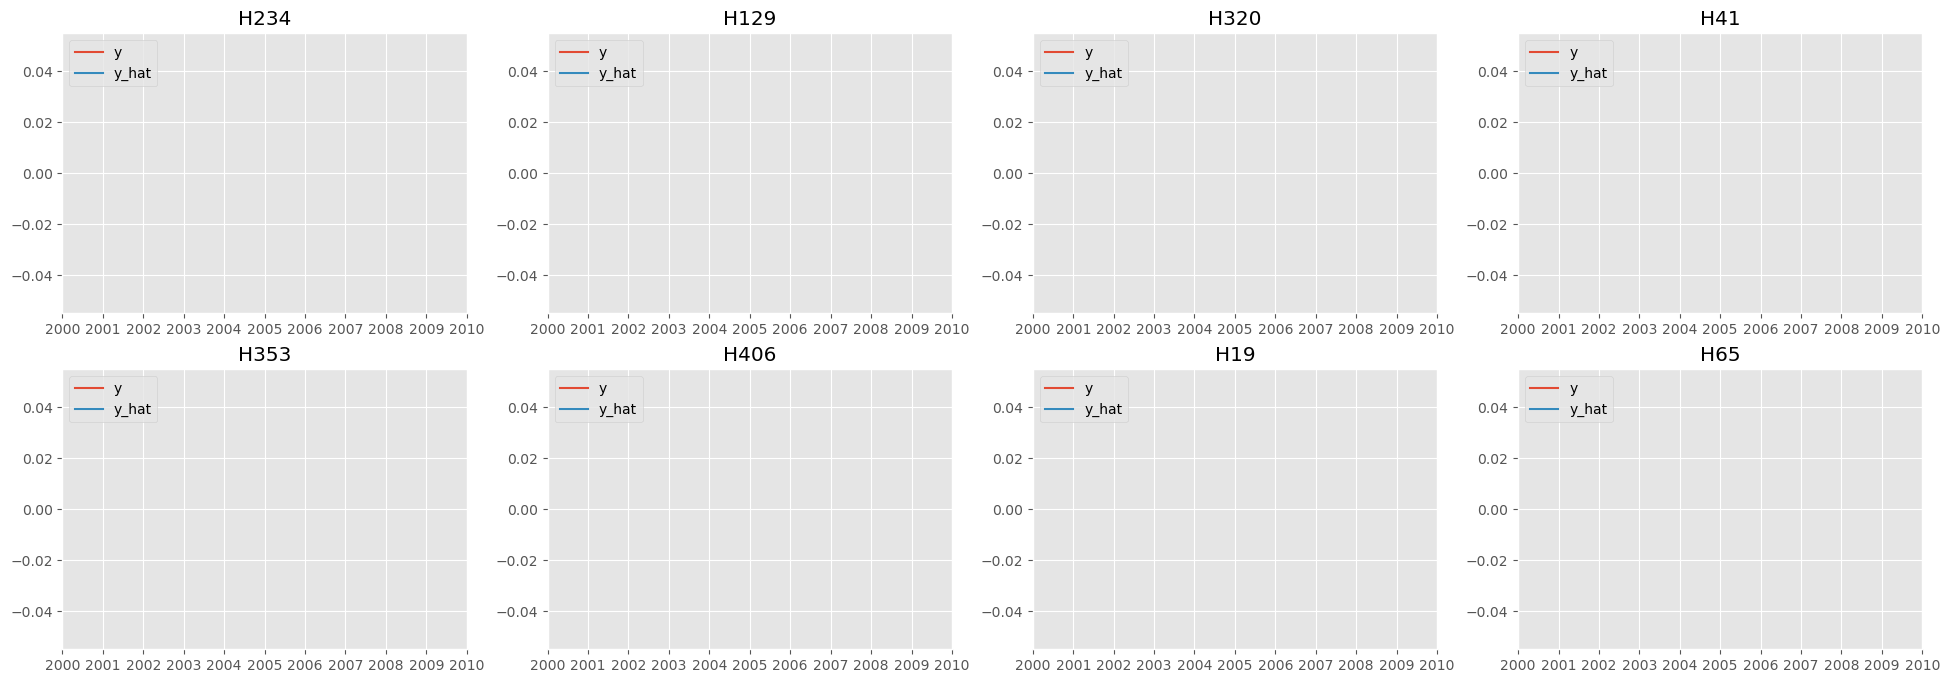

In [156]:
unique_ids = ['H129', 'H41', 'H406', 'H234', 
               'H65', 'H19', 'H320', 'H353']

plot_preds = pd.concat([y_train_df.groupby('unique_id').tail(50), 
                        y_test_df],  sort=True)

plot_grid_prediction(plot_preds, y_hat_df,  unique_ids=unique_ids)

In [73]:
import pandas as pd
import numpy as np
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import shuffle

# Load the Excel file
file_path = "ES_RNN preprocess.xlsx"  # Replace with your actual file path
df = pd.read_excel(file_path)

# Define features and target variable
X, y = shuffle(df[["ds", "id"]], df["y"], random_state=13)
X = X.astype(np.float32)

# Split data into training and test sets (90% train, 10% test)
offset = int(X.shape[0] * 0.9)
X_train, y_train = X[:offset], y[:offset]
X_test, y_test = X[offset:], y[offset:]

# Initialize and run LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# Print model performance
print(models)


 98%|█████████████████████████████████████████▉ | 41/42 [01:10<00:01,  1.11s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 15968, number of used features: 2
[LightGBM] [Info] Start training from score 334.642140


100%|███████████████████████████████████████████| 42/42 [01:10<00:00,  1.69s/it]

                               Adjusted R-Squared  R-Squared   RMSE  \
Model                                                                 
BaggingRegressor                             0.58       0.58 417.36   
RandomForestRegressor                        0.56       0.56 424.81   
ExtraTreesRegressor                          0.55       0.55 429.61   
LGBMRegressor                                0.54       0.54 435.63   
HistGradientBoostingRegressor                0.50       0.50 455.87   
GradientBoostingRegressor                    0.42       0.42 489.53   
DecisionTreeRegressor                        0.29       0.29 542.94   
XGBRegressor                                 0.25       0.25 555.61   
ExtraTreeRegressor                           0.15       0.15 594.48   
GaussianProcessRegressor                     0.04       0.04 629.59   
MLPRegressor                                 0.02       0.02 638.28   
KNeighborsRegressor                          0.01       0.01 639.22   
SGDReg